# Linear Models and Generalized Linear Models


## Week 8 Homework

---

### Q1: derive the following

1. $p(\boldsymbol \beta | \textbf{y}, \textbf{X}, \Sigma=\sigma^2 I)$ for the **linear regression model** likelihood proportional to $\exp \left(-{\frac {1}{2}}(\mathbf {y} -\mathbf{X\boldsymbol \beta})^\top \Sigma^{-1}(\mathbf {y} - \mathbf{X\boldsymbol\beta})\right)$ and a ${MVN}(\boldsymbol\beta_0, \boldsymbol\Sigma_\beta)$ for $\boldsymbol\beta$

2. The analytical posterior distribution for $\sigma^2$ the **error variance** of a **linear regression model** with **design matrix** $\mathbf{X}$ assuming $\sigma^2$ has an **inverse-gamma** prior distribution with parameters $\alpha^*$ and $\beta^*$ (unrelated to $\boldsymbol \beta$).

#### [Optional] Q1 Extra: derive the following

Show that for $s_i=1$ and **hyperparameters** $b_i=0$ (ignoring normalizing proportionality constants) the log posterior distributions for $\beta$ using either **normal** or **Laplace** prior distributions have analagous forms to the **ridge** and **lasso** loss functions.

*Note though that Bayesians do not optimize posterior distributions, they sample from them; but, nonetheless, the posterior distributions serve to provided 'regularizeations' of the likelihood through the prior.*


### Q1.1
$
\begin{align*}
\mathbf{y} &\sim{} MVN\left(\mathbf{X}  \boldsymbol \beta, \Sigma = \sigma^2 I \right) \quad \text{-- MVN disttribution} \\
\\
p(\mathbf{y} | \mathbf{X}, \boldsymbol{\beta}, \Sigma) &\propto \exp \left(-\frac{1}{2} (\mathbf{y} - \mathbf{X} \boldsymbol{\beta})^\top \Sigma^{-1} (\mathbf{y} - \mathbf{X} \boldsymbol{\beta}) \right) \quad \text{-- likelihood function} \\
\\
\boldsymbol{\beta} &\sim MVN(\boldsymbol{\beta}_0, \Sigma_{\beta}) \quad \text{-- prior for \( \boldsymbol{\beta} \)} \\
p(\boldsymbol{\beta}) &\propto \exp \left( -\frac{1}{2} (\boldsymbol{\beta} - \boldsymbol{\beta}_0)^\top \Sigma_{\beta}^{-1} (\boldsymbol{\beta} - \boldsymbol{\beta}_0) \right) \quad \text{-- prior density function from \( MVN(\boldsymbol{\beta}_0, \Sigma_{\beta}) \)} \\
\\
p(\boldsymbol{\beta} | \mathbf{y}, \mathbf{X}, \Sigma) &\propto p(\mathbf{y} | \mathbf{X}, \boldsymbol{\beta}, \Sigma) \cdot p(\boldsymbol{\beta}) \quad \text{-- applying Bayes' theorem} \\
\\
&\propto \exp \left( -\frac{1}{2} (\mathbf{y} - \mathbf{X} \boldsymbol{\beta})^\top \Sigma^{-1} (\mathbf{y} - \mathbf{X} \boldsymbol{\beta}) \right) \times \exp \left( -\frac{1}{2} (\boldsymbol{\beta} - \boldsymbol{\beta}_0)^\top \Sigma_{\beta}^{-1} (\boldsymbol{\beta} - \boldsymbol{\beta}_0) \right) \\
\quad &\text{-- combining likelihood and prior exponentials} \\
\\
&\propto \exp \left( -\frac{1}{2} \left[ \boldsymbol{\beta}^\top (\mathbf{X}^\top \Sigma^{-1} \mathbf{X} + \Sigma_{\beta}^{-1}) \boldsymbol{\beta} - 2 \boldsymbol{\beta}^\top (\mathbf{X}^\top \Sigma^{-1} \mathbf{y} + \Sigma_{\beta}^{-1} \boldsymbol{\beta}_0) \right] \right) \quad \text{-- completing the square} \\
\\
\boldsymbol{\beta} | \mathbf{y}, \mathbf{X}, \Sigma &\sim MVN \left( ( \mathbf{X}^\top \Sigma^{-1} \mathbf{X} + \Sigma_{\beta}^{-1} )^{-1} ( \mathbf{X}^\top \Sigma^{-1} \mathbf{y} + \Sigma_{\beta}^{-1} \boldsymbol{\beta}_0 ), ( \mathbf{X}^\top \Sigma^{-1} \mathbf{X} + \Sigma_{\beta}^{-1} )^{-1} \right) \quad \text{-- posterior distribution of \( \boldsymbol{\beta} \)} \\
\end{align*}
$

### Q1.2

$
\begin{align*}
y_i | X, \beta, \sigma^2 &\sim N(X\beta, \sigma^2) \quad \text{-- likelihood assumption} \\
\sigma^2 &\sim InverseGamma(\alpha, \beta) \quad \text{-- prior assumption (inverse-gamma prior)} \\
\\
p(y | X, \beta, \sigma^2) &\propto (\sigma^2)^{-n/2} \exp \left( -\frac{1}{2\sigma^2} (y - X\beta)^\top (y - X\beta) \right) \quad \text{-- likelihood function} \\
p(\sigma^2) &\propto (\sigma^2)^{-(\alpha + 1)} \exp \left( -\frac{\beta}{\sigma^2} \right) \quad \text{-- prior} \\
\\
p(\sigma^2 | y, X, \beta) &\propto p(y | X, \beta, \sigma^2) p(\sigma^2) \quad \text{-- Bayes' theorem} \\
&\propto (\sigma^2)^{-(\alpha + n/2 + 1)} \exp \left( -\frac{\beta + \frac{1}{2} (y - X\beta)^\top (y - X\beta)}{\sigma^2} \right) \\
\\
\sigma^2 | y, X, \beta &\sim IG(\alpha^*, \beta^*) \quad \text{-- posterior follows an inverse-gamma distribution} \\
\alpha^* &= \alpha + \frac{n}{2} \\
\beta^* &= \beta + \frac{1}{2} (y - X\beta)^\top (y - X\beta) \quad \text{-- updated parameters}
\end{align*}
$

#### Q1 Extra: Ridge and Lasso from Bayesian Priors
$
\begin{align*}
\text{Ridge Regression (L2 Regularization)}:\\
p(\beta) &\sim N(0, \lambda I) \quad \text{-- Normal prior} \\
\log p(\beta | y, X) &\propto -\frac{1}{2} \| y - X\beta \|^2 - \frac{\lambda}{2} \| \beta \|^2 \quad \text{-- log-posterior matches Ridge objective} \\
\\
\text{Lasso Regression (L1 Regularization)}:\\
p(\beta) &\sim \text{Laplace}(0, b) \quad \text{-- Laplace prior} \\
\log p(\beta | y, X) &\propto -\frac{1}{2} \| y - X\beta \|^2 - \lambda \sum |\beta_i| \quad \text{-- log-posterior matches Lasso objective}
\end{align*}
$

**Normal priors correspond to Ridge regression**, while **Laplace priors correspond to Lasso regression**.


### Q2: perform Bayesian Linear Regression

- For any data set you find interesting (perhaps from kaggle.com?)
- Use an appropriate non **inverse-gamma** prior for `sigma`
- Use `pm.Normal('betas', mu=0, sigma=1, shape=p)` rather than a `pm.MvNormal` alternative
- Use `pm.Normal('y', mu=X@betas, sigma=sigma, observed=y)` rather than `pm.MvNormal` alternative
- Provide inference with Bayesian posterior analysis and report MCMC diagnostics

#### [Optional] Q2 Extra: perform generalized Bayesian Linear Regression

Replace the residual distribution and use an appropriate link function

In [58]:
import kagglehub
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Download latest version
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
# print("Path to dataset files:", path)
file_path = f"{path}/Clean_Dataset.csv"  # Update this if necessary

# Read data
df = pd.read_csv(file_path)
# df.columns

# Select features and target variable
target_col = "price"
feature_cols = ["source_city", "stops", "destination_city", "class", "duration", "days_left"]  # Predictors

# Drop missing values in relevant columns
df = df[[target_col] + feature_cols].dropna()

# One-hot encode categorical features
df = pd.get_dummies(df, columns=["source_city", "destination_city", "class"], drop_first=True)
df["stops"] = df["stops"].map({"zero": 0, "one": 1}).fillna(2).astype(int)

# Explicitly update feature_cols after encoding
feature_cols = [col for col in df.columns if col != target_col]

# Randomly sample 5000 data points
df_sample = df.sample(n=5000)

# Define X (features) and y (target) for the subset
X = df_sample[feature_cols].values.astype(float)
y = df_sample[target_col].values.astype(float)

# Add an intercept term
X = np.column_stack((np.ones(X.shape[0]), X))

# Update n and p after subsampling
n, p = X.shape
print(X.shape)

# Bayesian Linear Regression Model
with pm.Model() as bayesian_linear_model:
    # Prior for regression coefficients (betas)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=p)

    # Prior for noise (sigma) using a Half-Normal
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Likelihood (Linear Model)
    y_obs = pm.Normal("y_obs", mu=X@betas, sigma=sigma, observed=y)

    # MCMC Sampling
    trace = pm.sample(2000, return_inferencedata=True)


(5000, 15)


Output()

               mean     sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]     22.685  0.958    20.915    24.472      0.011    0.008    7606.0   
betas[1]     22.786  0.983    20.928    24.653      0.011    0.008    8349.0   
betas[2]    324.902  0.878   323.331   326.569      0.011    0.008    6727.0   
betas[3]    342.592  0.592   341.415   343.663      0.007    0.005    8074.0   
betas[4]      3.028  0.997     1.135     4.857      0.011    0.009    7641.0   
betas[5]      3.272  0.979     1.453     5.107      0.011    0.009    7438.0   
betas[6]      2.941  1.005     1.078     4.774      0.012    0.009    7426.0   
betas[7]      3.865  1.007     2.075     5.808      0.011    0.008    8492.0   
betas[8]      5.363  1.021     3.470     7.290      0.012    0.009    6852.0   
betas[9]      3.301  1.009     1.398     5.211      0.010    0.008    9508.0   
betas[10]     3.813  1.033     2.016     5.941      0.011    0.009    8997.0   
betas[11]     2.253  0.997     0.415    

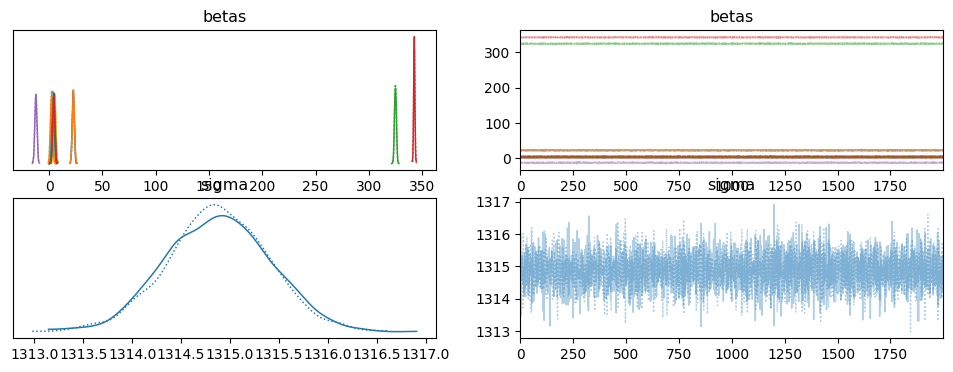

Output()

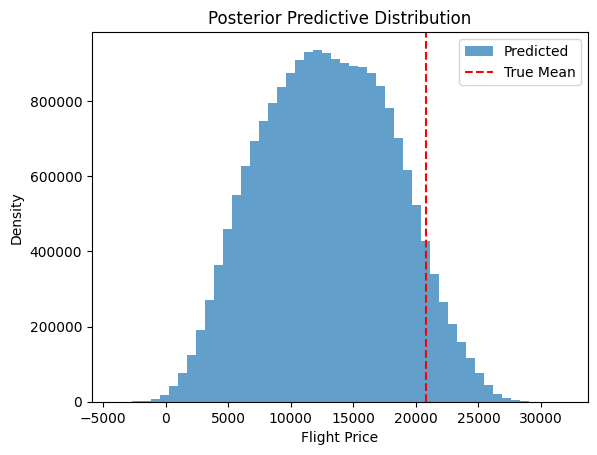

In [59]:
# Summary statistics
print(az.summary(trace))
az.plot_trace(trace)
plt.show()

with bayesian_linear_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)

# Extract posterior predictive samples correctly
y_pred_samples = posterior_predictive.posterior_predictive["y_obs"].values.flatten()

# Plot the predictive distribution
plt.hist(y_pred_samples, bins=50, alpha=0.7, label="Predicted")
plt.axvline(y.mean(), color="red", linestyle="dashed", label="True Mean")
plt.legend()
plt.xlabel("Flight Price")
plt.ylabel("Density")
plt.title("Posterior Predictive Distribution")
plt.show()


### Q3: perform robust Bayesian Linear Regression

Let $p(\tau_i)$ be $\require{cancel} \textrm{gamma}\big(\tau_i | \alpha = \frac{\nu}{2}, \overset{\textrm{rate}\xcancel{\textrm{scale}}}{\beta = \frac{\nu}{2}}\big)$ and let $p(y_i|\boldsymbol \beta, \tau,\tau_i)$ be $N(y_i | \textbf{X} \boldsymbol \beta, \overset{\textrm{precision}}{\tau \times \tau_i})$.

- Return to your dataset and maniputate it to have some various outliers or find another dataset with some outlier data
- Use an appropriate prior for inference on $v$ if you have enough data to do so
- Use the posterior distributions of the $\tau_i$'s to identify data point "outliers"
- Use the posterior distributions of the $\sigma_i^{-2} = \tau \times \tau_i$ to create posterior distribuitions of the **influence** (the diagonals of the $H$ "hat" matrix $X^\top (X^\top D X)^{-1} X$ where $D_{ij}=0$ and $D_{ii} = \sigma^2_i$) and compare and contras some example "outlier" versus "non outlier" data points

- Provide inference with Bayesian posterior analysis and report MCMC diagnostics

#### [Optional] Q3 Extra: measurement error models?

What if $\textbf{x}_i = \textbf{x}_i^{true} + \eta_i, \eta_i \sim MVN(\textbf{0}, \Sigma)$ for some kind of measurement error covariance structure $\Sigma$ and $N (y_i| \textbf{X}^{true}\boldsymbol \beta, \sigma)$?


In [61]:
with pm.Model() as robust_bayesian_linear_model:
# existing code already has outliers.

    # Prior for regression coefficients (betas)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=p)

    # prior for nu.
    # Hyperprior for ν (degrees of freedom for robustness)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    # Gamma-distributed tau_i (latent precision for each data point)
    tau_i = pm.Gamma("tau_i", alpha=nu / 2, beta=nu / 2, shape=n)

    # Global noise precision (τ)
    tau = pm.Gamma("tau", alpha=2, beta=2)

    # Compute sigma_i from precision values
    sigma_i = 1 / pm.math.sqrt(tau * tau_i)  # Converts precision to std dev

    # Likelihood (Robust Linear Model)
    y_obs = pm.Normal("y_obs", mu=X @ betas, sigma=sigma_i, observed=y)

    # MCMC Sampling
    trace = pm.sample(1000, return_inferencedata=True)



Output()

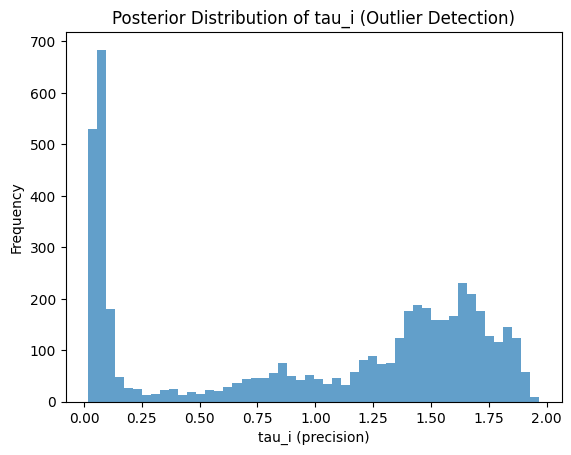

Potential Outlier Indices: [1709 4590 3581  552 2118 2515 2119 3536 2776 3659 3230 3925 3574 2816
 4215 4154 2117 2846 3845  665   42 3824 3660 1302 1501  169  270 2187
 4631  302 2668  730 3193 3949 1039 1161 2290 3725 2199 1073 1449 1637
 2692 1947 2975  748   17 3831 2361  296]


In [69]:
# Getting Outliers

# Extract posterior mean of tau_i
tau_i_posterior_mean = trace.posterior["tau_i"].mean(dim=["chain", "draw"]).values.flatten()

# Plot tau_i to visualize potential outliers
plt.hist(tau_i_posterior_mean, bins=50, alpha=0.7)
plt.xlabel("tau_i (precision)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of tau_i (Outlier Detection)")
plt.show()

# Identify data points with smallest tau_i (potential outliers)
outlier_indices = np.argsort(tau_i_posterior_mean)[:50]
print("Potential Outlier Indices:", outlier_indices)


Total data points: 5000
Min influence: 0.0, Max influence: 1.0
Outliers detected: 1510
Outlier influence values: [0.10882576 0.11755959 0.04569653 ... 0.15180234 0.22168507 0.10427217]


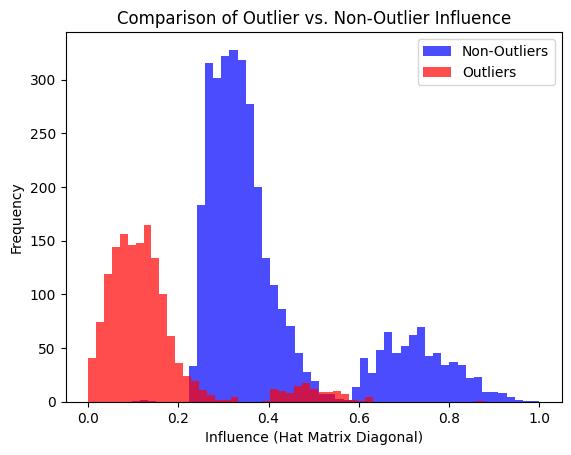

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Extract posterior mean of tau_i
tau_i_posterior_mean = trace.posterior["tau_i"].mean(dim=["chain", "draw"]).values.flatten()

# Compute mean of tau (global precision parameter)
tau_mean = trace.posterior["tau"].mean(dim=["chain", "draw"]).values.item()  # Extract scalar value

# Compute sigma_i_squared (inverse variance)
sigma_i_squared = 1 / (tau_mean * tau_i_posterior_mean)

# Compute the hat matrix H
XTX_inv = np.linalg.inv(X.T @ (X * sigma_i_squared[:, np.newaxis]))  # Adjusted multiplication
H = X @ XTX_inv @ X.T  # Hat matrix

# Extract diagonal (influence of each point)
influence = np.diag(H)

# Ensure numerical stability (normalize influence)
influence = (influence - np.min(influence)) / (np.max(influence) - np.min(influence))

# Compute z-scores for tau_i posterior means
tau_i_zscores = zscore(tau_i_posterior_mean)

# Detect outliers using z-score threshold
outlier_indices = np.where(tau_i_zscores < -1)[0]  # Use -1.5 for a more sensitive threshold

# Ensure at least one outlier exists
if len(outlier_indices) == 0:
    print("No extreme outliers detected, forcing selection of smallest tau_i value as an outlier.")
    outlier_indices = [np.argmin(tau_i_posterior_mean)]  # Select smallest tau_i value

# Debugging Information
print(f"Total data points: {len(influence)}")
print(f"Min influence: {np.min(influence)}, Max influence: {np.max(influence)}")
print(f"Outliers detected: {len(outlier_indices)}")
if len(outlier_indices) > 0:
    print(f"Outlier influence values: {influence[outlier_indices]}")

# Compare outlier vs. non-outlier influence
outlier_influence = influence[outlier_indices]
non_outlier_influence = np.delete(influence, outlier_indices)

# Plot influence distributions
plt.hist(non_outlier_influence, bins=50, alpha=0.7, label="Non-Outliers", color="blue")
plt.hist(outlier_influence, bins=50, alpha=0.7, label="Outliers", color="red")
plt.legend()
plt.xlabel("Influence (Hat Matrix Diagonal)")
plt.ylabel("Frequency")
plt.title("Comparison of Outlier vs. Non-Outlier Influence")
plt.show()


In [81]:
# Diagnostics
print(az.summary(trace))
# ESS & R-hat diagnostics
print("Effective Sample Size (ESS):")
print(az.ess(trace, var_names=["betas", "tau", "nu"]))

print("\nR-hat Diagnostics (should be close to 1):")
print(az.rhat(trace, var_names=["betas", "tau", "nu"]))

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
betas[0]     0.365  0.979  -1.453    2.206      0.016    0.024    3711.0   
betas[1]     0.317  0.998  -1.636    2.077      0.017    0.025    3356.0   
betas[2]     4.211  1.008   2.356    6.121      0.015    0.011    4193.0   
betas[3]     8.571  1.005   6.723   10.395      0.019    0.013    2833.0   
betas[4]     0.029  0.976  -1.855    1.750      0.017    0.025    3312.0   
...            ...    ...     ...      ...        ...      ...       ...   
tau_i[4995]  1.377  1.328   0.000    3.824      0.025    0.021    2268.0   
tau_i[4996]  1.438  1.415   0.000    3.953      0.024    0.021    2180.0   
tau_i[4997]  0.699  0.684   0.000    1.966      0.012    0.012    2803.0   
tau_i[4998]  1.519  1.432   0.005    4.169      0.027    0.023    2444.0   
tau_i[4999]  1.409  1.347   0.008    4.018      0.025    0.022    1943.0   

             ess_tail  r_hat  
betas[0]       1760.0    1.0  
betas[1]       1196.0    